In [64]:
import pandas as pd
import os
import json
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import numpy as np

In [65]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [66]:
# Enable automatic reloading of modules before executing user code (useful during development)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
PARQUET_PATH = os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars.parquet")
JSON_METADATA_PATH =os.path.join(PROCESSED_DATA_DIR_PATH, "panel_2002_2022_136countries_68vars_metadata.json")

In [68]:
# Load dataframe
df = pd.read_parquet(PARQUET_PATH)
df.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_cumulative_climate_laws,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 71 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

In [70]:
# Load metadata
with open(JSON_METADATA_PATH, "r") as file:
    df_metadata = json.load(file) 
df_metadata.keys()

dict_keys(['configuration', 'dimensions', 'zero_filled_variables'])

In [71]:
# Obtain emission fields
emission_fields = df_metadata["dimensions"]["EMISSIONS"]
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_intensity',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_mt',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [72]:
df[emission_fields]

,con_co2_incl_luc_mt,con_co2_intensity,con_co2_mt,con_co2_per_capita,con_edgar_ghg_mt,con_edgar_ghg_gg,con_ghg_per_capita,con_methane_mt,con_nitrous_oxide_mt,con_share_global_co2_pct,con_total_emissions,con_total_ghg_mt
0,6.391,169.01,1.341,0.063,17.044710,17044.710352,0.937,10.375,3.299,0.005,0.12,20.037
1,6.169,241.76,1.560,0.069,17.732318,17732.317739,0.914,10.687,3.434,0.006,0.22,20.769
2,3.636,227.85,1.237,0.053,17.789451,17789.451447,0.804,10.651,3.412,0.004,0.18,18.934
3,2.983,219.51,1.890,0.077,18.191324,18191.324358,0.787,10.901,3.561,0.006,0.18,19.199
4,3.244,255.56,2.159,0.085,18.461036,18461.036258,0.764,11.122,3.418,0.007,0.23,19.426
...,...,...,...,...,...,...,...,...,...,...,...,...
2851,10.131,395.55,11.209,0.746,31.273375,31273.374543,1.813,11.831,5.206,0.031,3.73,27.250
2852,16.597,429.25,10.267,0.672,30.207339,30207.339246,2.008,11.636,5.099,0.028,3.64,30.672
2853,7.897,371.09,8.491,0.547,28.341567,28341.566541,1.555,11.314,4.591,0.024,2.49,24.146
2854,12.444,269.55,10.223,0.647,29.525357,29525.356700,1.767,11.840,4.858,0.028,2.31,27.907


In [73]:
# define target variable
target_var = "con_edgar_ghg_mt"

## Data prep

### Load carbon tax stock and add it as a feature

In [74]:
carbon_tax_stock_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_carbon_policy_stock.csv"))
carbon_tax_stock_df.head()

,iso_alpha_3,year,policy_stock
0,MAR,2002,0
1,MAR,2003,0
2,MAR,2004,0
3,MAR,2005,0
4,MAR,2006,1


In [75]:
df_merged = pd.merge(df, carbon_tax_stock_df, how="left", on=["iso_alpha_3", "year"])
df_merged.head()

,iso_alpha_3,year,country_name,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,...,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,policy_stock
0,AFG,2002,Afghanistan,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,AFG,2003,Afghanistan,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,AFG,2004,Afghanistan,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,AFG,2005,Afghanistan,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,AFG,2006,Afghanistan,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [76]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 72 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

In [77]:
# fill nulls in policy stock with zeros
df_merged["policy_stock"] = df_merged["policy_stock"].fillna(0)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 72 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   iso_alpha_3                                2856 non-null   object 
 1   year                                       2856 non-null   int64  
 2   country_name                               2856 non-null   object 
 3   cap_gdp_current_usd                        2856 non-null   float64
 4   cap_gdp_per_capita_constant_2015           2856 non-null   float64
 5   cap_gdp_per_capita_ppp_current             2856 non-null   float64
 6   cap_population                             2856 non-null   float64
 7   cap_electoral_democracy_idx                2856 non-null   float64
 8   cap_liberal_democracy_idx                  2856 non-null   float64
 9   cap_corruption_idx                         2856 non-null   float64
 10  cap_rule_of_law_idx     

### Filter data to avoid leakage

In [78]:
emission_fields.remove(target_var)
emission_fields.remove('con_co2_intensity')
emission_fields

['con_co2_incl_luc_mt',
 'con_co2_mt',
 'con_co2_per_capita',
 'con_edgar_ghg_gg',
 'con_ghg_per_capita',
 'con_methane_mt',
 'con_nitrous_oxide_mt',
 'con_share_global_co2_pct',
 'con_total_emissions',
 'con_total_ghg_mt']

In [79]:
df_filtered = df_merged.drop(columns=emission_fields + ["country_name"])
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_gdp_current_usd',
       'cap_gdp_per_capita_constant_2015', 'cap_gdp_per_capita_ppp_current',
       'cap_population', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_civil_liberties_idx', 'cap_control_corruption',
       'cap_govt_effectiveness', 'cap_political_stability',
       'cap_regulatory_quality', 'cap_rule_of_law', 'cap_voice_accountability',
       'con_agricultural_land_pct', 'con_bioenergy', 'con_coal', 'con_demand',
       'con_demand_per_capita', 'con_electricity_access_pct',
       'con_electricity_generation_twh', 'con_energy_per_capita_kwh',
       'con_forest_area_pct', 'con_fossil_share_elec_pct', 'con_gas',
       'con_gas_and_other_fossil', 'con_hydro',
       'con_hydro,_bioenergy_and_other_renewables', 'con_net_elec_imports_twh',
       'con_nuclear', 'con_other_fossil', 'con_population',
       'con_primary_energy_twh'

### Fix Skewness

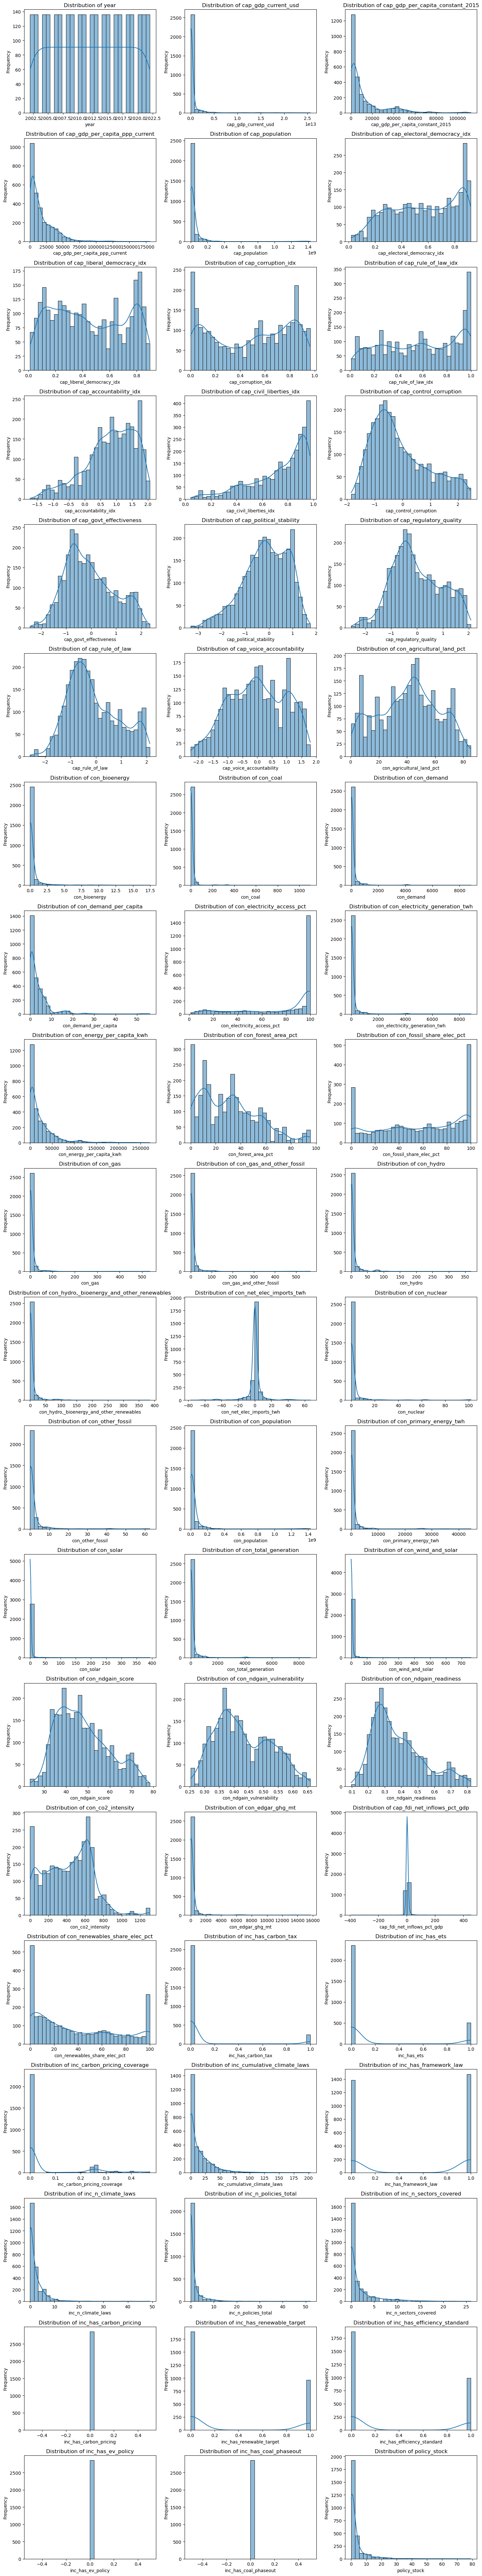

In [80]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [81]:
df_filtered.describe()

,year,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_accountability_idx,...,inc_has_framework_law,inc_n_climate_laws,inc_n_policies_total,inc_n_sectors_covered,inc_has_carbon_pricing,inc_has_renewable_target,inc_has_efficiency_standard,inc_has_ev_policy,inc_has_coal_phaseout,policy_stock
count,2856.000000,2.856000e+03,2856.000000,2856.000000,2.856000e+03,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,...,2856.000000,2856.000000,2856.000000,2856.000000,2856.0,2856.000000,2856.000000,2856.0,2856.0,2856.000000
mean,2012.000000,4.549098e+11,12569.581328,17825.876908,4.474379e+07,0.566125,0.447432,0.487975,0.575038,0.801282,...,0.515406,2.184174,1.440476,1.761204,0.0,0.337535,0.345588,0.0,0.0,3.563375
std,6.056361,1.823163e+12,17858.950458,20297.376882,1.618958e+08,0.247124,0.262918,0.313468,0.308789,0.789647,...,0.499850,3.496865,3.233141,3.296187,0.0,0.472952,0.475643,0.0,0.0,7.158122
min,2002.000000,8.517107e+07,243.076666,492.840755,8.247500e+04,0.019000,0.012000,0.002000,0.010000,-1.725000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000
25%,2007.000000,1.017460e+10,1380.254844,3590.244442,3.263544e+06,0.353000,0.217000,0.170000,0.300500,0.356500,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000
50%,2012.000000,3.302481e+10,4789.834002,10813.936025,9.695688e+06,0.582000,0.421000,0.532000,0.592500,0.899000,...,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,1.000000
75%,2017.000000,1.894862e+11,15053.013707,25802.122340,2.838703e+07,0.801000,0.688000,0.784000,0.871000,1.429250,...,1.000000,3.000000,1.000000,2.000000,0.0,1.000000,1.000000,0.0,0.0,3.000000
max,2022.000000,2.560485e+13,112417.876989,180939.439450,1.425423e+09,0.923000,0.897000,0.965000,0.999000,2.056000,...,1.000000,49.000000,52.000000,26.000000,0.0,1.000000,1.000000,0.0,0.0,79.000000


In [82]:
# Identify full o zeros and drop them
zero_cols = df_filtered.columns[(df_filtered == 0).all()]
df_filtered = df_filtered.drop(columns=zero_cols)
print(zero_cols)


Index(['inc_has_carbon_pricing', 'inc_has_ev_policy', 'inc_has_coal_phaseout'], dtype='object')


In [83]:
# Identify binary columns
binary_cols = [
    c for c in df_filtered.columns
    if df_filtered[c].nunique(dropna=True) == 2
]
binary_cols


['inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard']

In [84]:
skew = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew.head(20)

con_solar                                    18.100333
con_wind_and_solar                           16.703063
con_coal                                     10.716587
con_gas                                      10.058157
con_gas_and_other_fossil                      9.636615
con_hydro                                     8.669590
cap_fdi_net_inflows_pct_gdp                   8.480725
con_edgar_ghg_mt                              8.467774
con_electricity_generation_twh                8.356955
con_total_generation                          8.356955
con_demand                                    8.351667
con_hydro,_bioenergy_and_other_renewables     8.346573
cap_gdp_current_usd                           8.097445
con_primary_energy_twh                        7.524785
con_population                                7.239620
cap_population                                7.233621
con_nuclear                                   6.399152
con_other_fossil                              6.160889
con_bioene

In [85]:
skew.tail(10)

cap_voice_accountability      -0.111544
cap_corruption_idx            -0.148069
cap_rule_of_law_idx           -0.172612
cap_electoral_democracy_idx   -0.224062
con_fossil_share_elec_pct     -0.295079
cap_political_stability       -0.516479
cap_accountability_idx        -0.708478
con_net_elec_imports_twh      -0.981781
cap_civil_liberties_idx       -1.038481
con_electricity_access_pct    -1.156544
dtype: float64

In [86]:
highly_skewed_fields = skew[skew.abs() >= 1].index.to_list()
highly_skewed_fields

['con_solar',
 'con_wind_and_solar',
 'con_coal',
 'con_gas',
 'con_gas_and_other_fossil',
 'con_hydro',
 'cap_fdi_net_inflows_pct_gdp',
 'con_edgar_ghg_mt',
 'con_electricity_generation_twh',
 'con_total_generation',
 'con_demand',
 'con_hydro,_bioenergy_and_other_renewables',
 'cap_gdp_current_usd',
 'con_primary_energy_twh',
 'con_population',
 'cap_population',
 'con_nuclear',
 'con_other_fossil',
 'con_bioenergy',
 'inc_n_policies_total',
 'con_demand_per_capita',
 'policy_stock',
 'inc_n_climate_laws',
 'con_energy_per_capita_kwh',
 'inc_cumulative_climate_laws',
 'inc_n_sectors_covered',
 'cap_gdp_per_capita_ppp_current',
 'cap_gdp_per_capita_constant_2015',
 'inc_carbon_pricing_coverage',
 'cap_civil_liberties_idx',
 'con_electricity_access_pct']

In [87]:
# Remove policy_stock from highly skewed
highly_skewed_fields.remove("policy_stock")

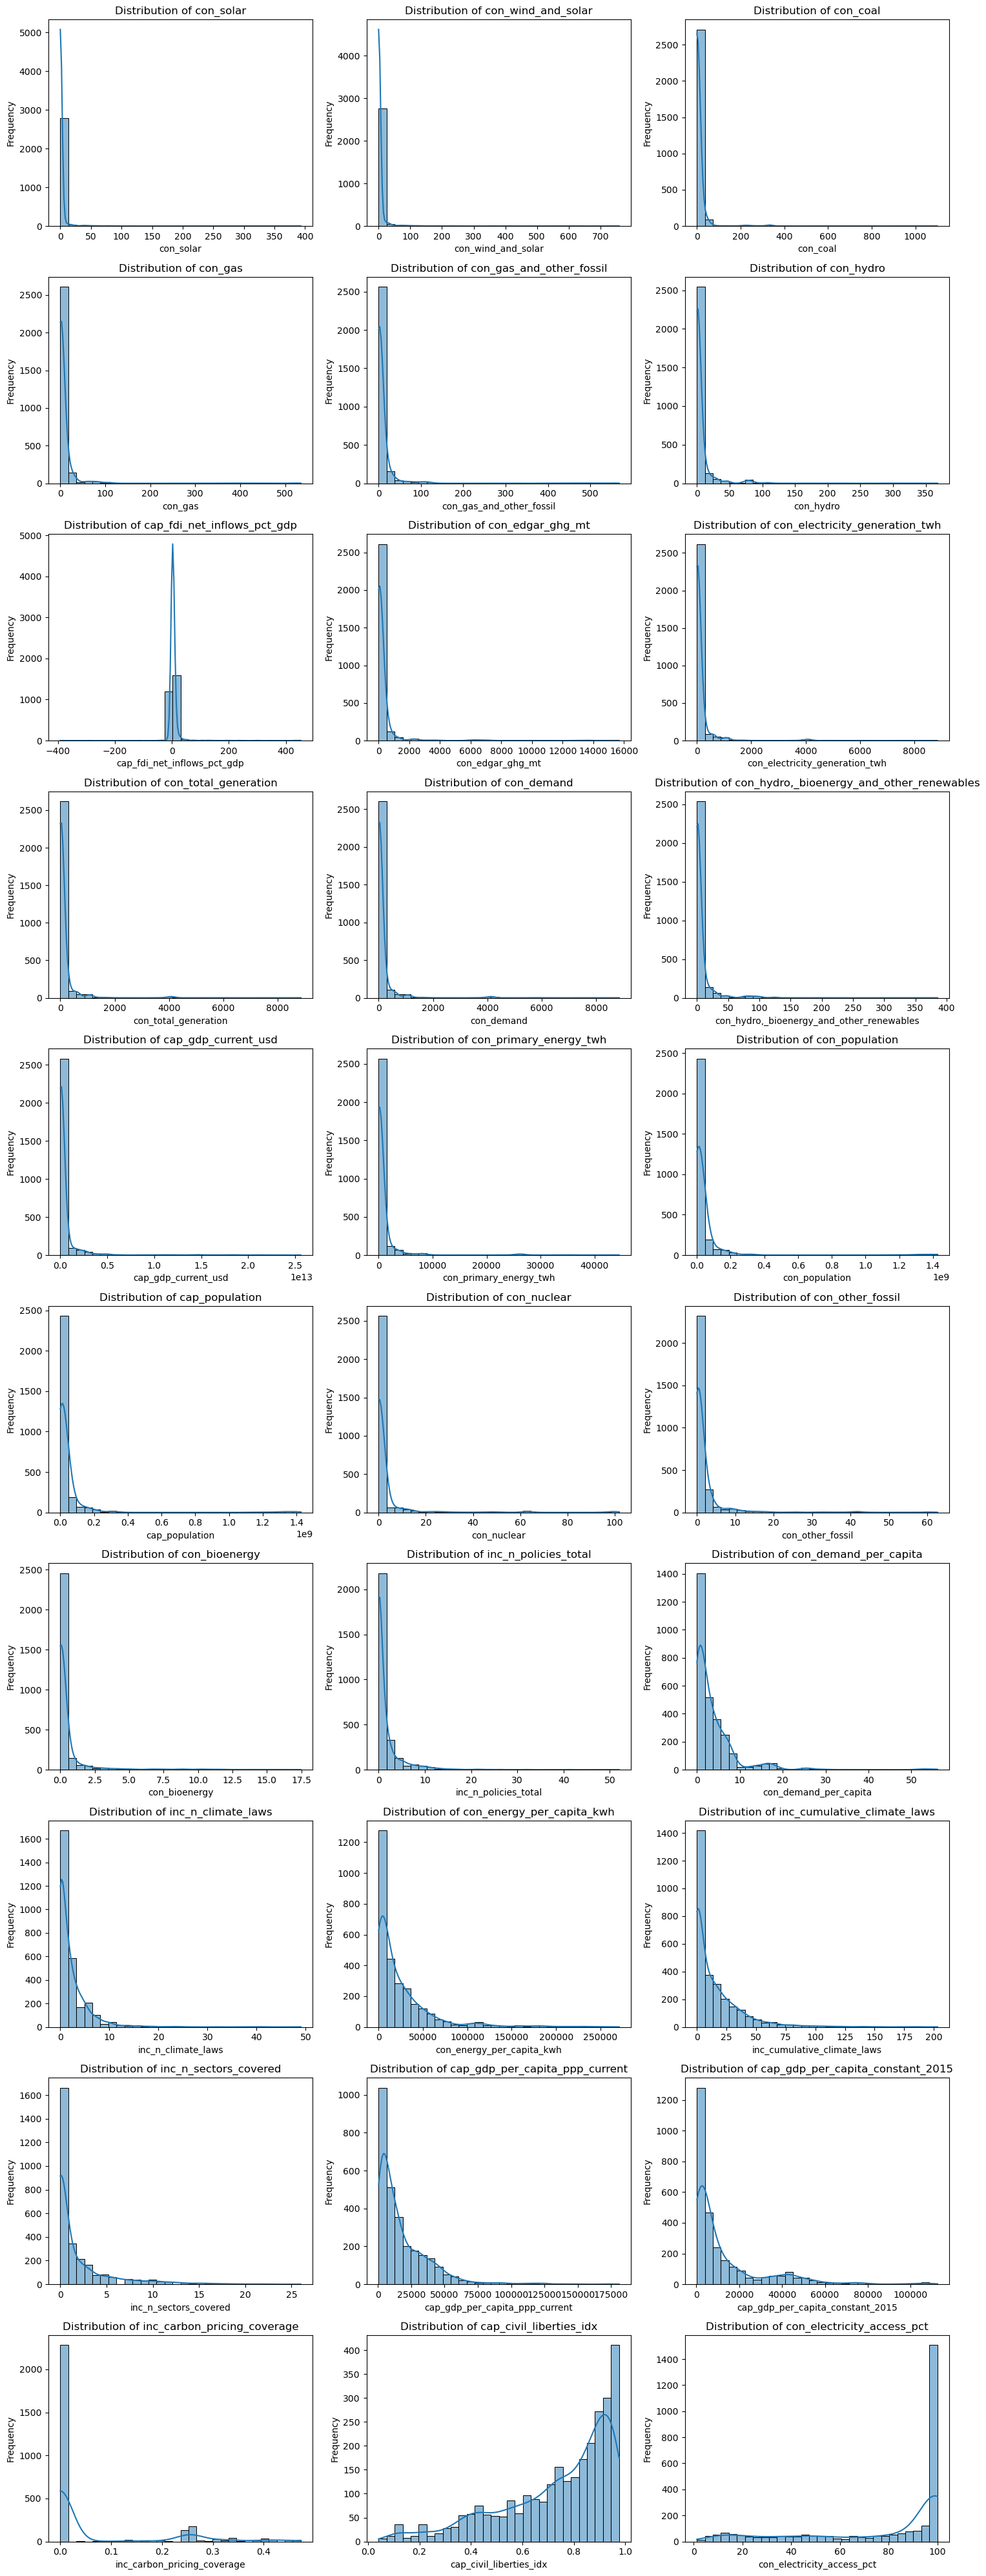

In [88]:
eda_utils.plot_numeric_fields_distributions(df_filtered[highly_skewed_fields])

In [89]:
# Log transform highly skewed fields
for field in highly_skewed_fields:
    df_filtered[f"x_log_signed_{field}"] = np.sign(df_filtered[field]) * np.log1p(np.abs(df_filtered[field]))
df_filtered.head()

,iso_alpha_3,year,cap_gdp_current_usd,cap_gdp_per_capita_constant_2015,cap_gdp_per_capita_ppp_current,cap_population,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,...,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_inc_n_sectors_covered,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_cap_gdp_per_capita_constant_2015,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,3.825701e+09,338.139974,926.507941,21378117.0,0.220,0.084,0.919,0.137,...,0.039221,0.0,5.054301,0.0,0.0,6.832501,5.826413,0.0,0.420682,2.714695
1,AFG,2003,4.520947e+09,346.071627,966.962032,22733049.0,0.227,0.086,0.919,0.129,...,0.039221,0.0,5.167969,0.0,0.0,6.875193,5.849531,0.0,0.438255,2.995732
2,AFG,2004,5.224897e+09,338.637274,971.633503,23560654.0,0.238,0.091,0.931,0.123,...,0.039221,0.0,5.067381,0.0,0.0,6.880007,5.827878,0.0,0.435671,3.210844
3,AFG,2005,6.203257e+09,363.640141,1076.087353,24404567.0,0.319,0.113,0.942,0.117,...,0.039221,0.0,5.330145,0.0,0.0,6.982016,5.898911,0.0,0.433080,3.391147
4,AFG,2006,6.971758e+09,367.758312,1121.834471,25424094.0,0.373,0.199,0.955,0.116,...,0.048790,0.0,5.552444,0.0,0.0,7.023612,5.910141,0.0,0.431782,3.540959


In [90]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 88 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   iso_alpha_3                                             2856 non-null   object 
 1   year                                                    2856 non-null   int64  
 2   cap_gdp_current_usd                                     2856 non-null   float64
 3   cap_gdp_per_capita_constant_2015                        2856 non-null   float64
 4   cap_gdp_per_capita_ppp_current                          2856 non-null   float64
 5   cap_population                                          2856 non-null   float64
 6   cap_electoral_democracy_idx                             2856 non-null   float64
 7   cap_liberal_democracy_idx                               2856 non-null   float64
 8   cap_corruption_idx                    

In [91]:
# Drop the skewed fields since we have the log transform version
df_filtered = df_filtered.drop(columns=highly_skewed_fields)

In [92]:
skew_after_log_transform = df_filtered[[col for col in df_filtered.columns if col not in binary_cols]].select_dtypes("number").skew().sort_values(ascending=False)
skew_after_log_transform.head(20)

policy_stock                                              4.507037
x_log_signed_con_solar                                    4.072531
x_log_signed_con_bioenergy                                3.204910
x_log_signed_con_wind_and_solar                           2.861822
x_log_signed_con_nuclear                                  2.769048
x_log_signed_con_coal                                     2.328500
x_log_signed_con_other_fossil                             1.994020
x_log_signed_inc_carbon_pricing_coverage                  1.766301
x_log_signed_con_hydro                                    1.589147
x_log_signed_con_hydro,_bioenergy_and_other_renewables    1.547016
x_log_signed_con_gas                                      1.486547
x_log_signed_inc_n_policies_total                         1.402111
x_log_signed_con_gas_and_other_fossil                     1.395439
x_log_signed_inc_n_sectors_covered                        1.126905
con_ndgain_readiness                                      0.85

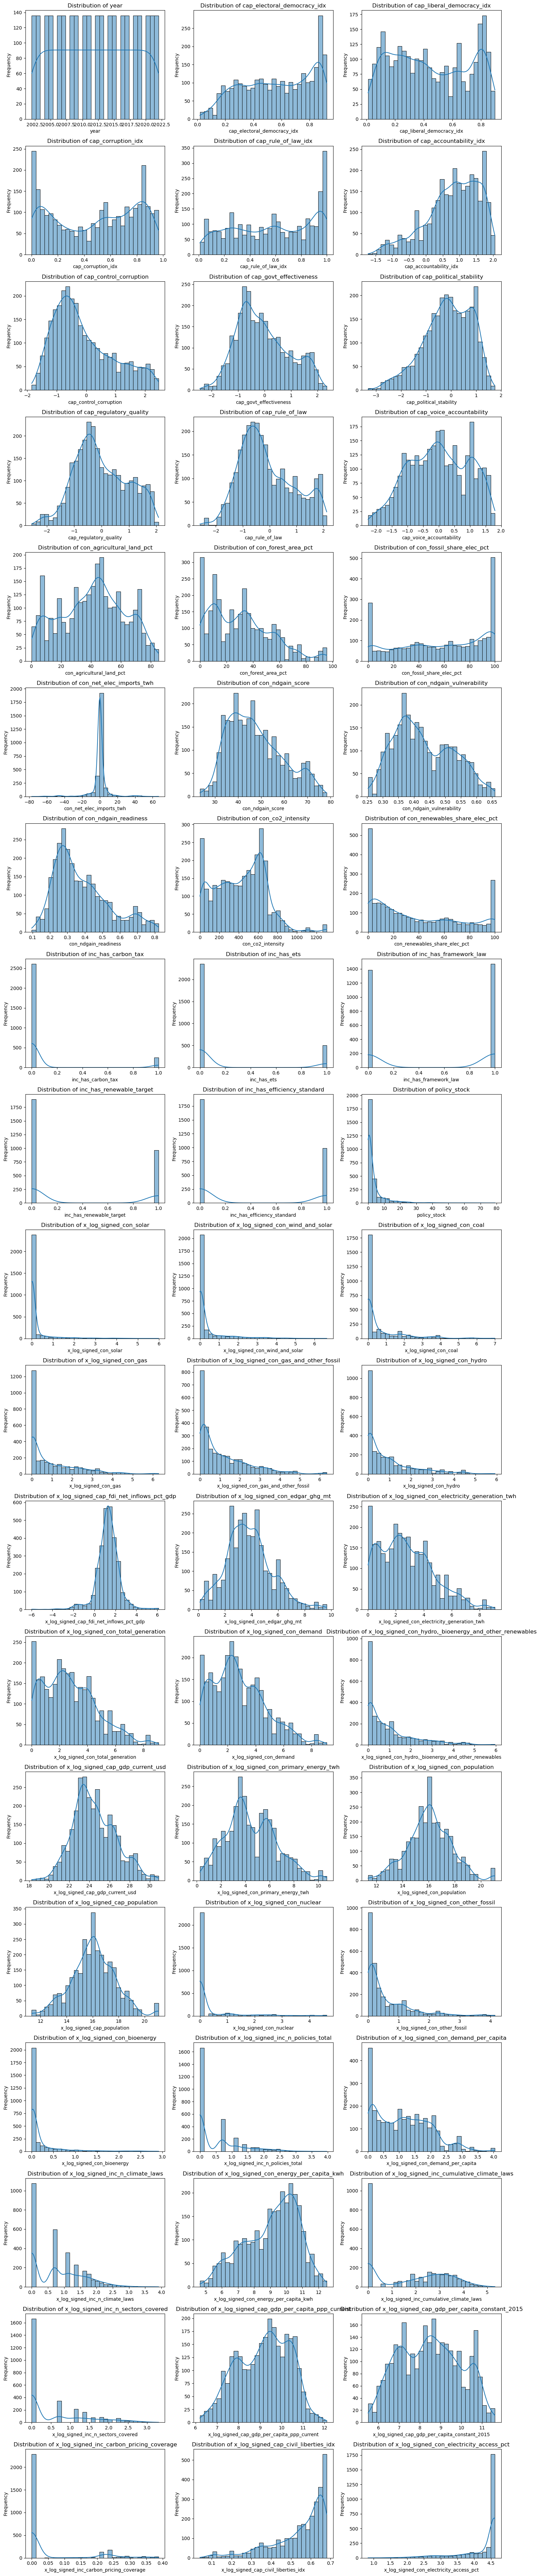

In [93]:
eda_utils.plot_numeric_fields_distributions(df_filtered)

In [95]:
df_filtered.columns

Index(['iso_alpha_3', 'year', 'cap_electoral_democracy_idx',
       'cap_liberal_democracy_idx', 'cap_corruption_idx',
       'cap_rule_of_law_idx', 'cap_accountability_idx',
       'cap_control_corruption', 'cap_govt_effectiveness',
       'cap_political_stability', 'cap_regulatory_quality', 'cap_rule_of_law',
       'cap_voice_accountability', 'con_agricultural_land_pct',
       'con_forest_area_pct', 'con_fossil_share_elec_pct',
       'con_net_elec_imports_twh', 'con_ndgain_score',
       'con_ndgain_vulnerability', 'con_ndgain_readiness', 'con_co2_intensity',
       'con_renewables_share_elec_pct', 'inc_has_carbon_tax', 'inc_has_ets',
       'inc_has_framework_law', 'inc_has_renewable_target',
       'inc_has_efficiency_standard', 'policy_stock', 'x_log_signed_con_solar',
       'x_log_signed_con_wind_and_solar', 'x_log_signed_con_coal',
       'x_log_signed_con_gas', 'x_log_signed_con_gas_and_other_fossil',
       'x_log_signed_con_hydro', 'x_log_signed_cap_fdi_net_inflows_pct_gd

## ML

In [96]:
training_df = df_filtered.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,cap_electoral_democracy_idx,cap_liberal_democracy_idx,cap_corruption_idx,cap_rule_of_law_idx,cap_accountability_idx,cap_control_corruption,cap_govt_effectiveness,cap_political_stability,...,x_log_signed_con_demand_per_capita,x_log_signed_inc_n_climate_laws,x_log_signed_con_energy_per_capita_kwh,x_log_signed_inc_cumulative_climate_laws,x_log_signed_inc_n_sectors_covered,x_log_signed_cap_gdp_per_capita_ppp_current,x_log_signed_cap_gdp_per_capita_constant_2015,x_log_signed_inc_carbon_pricing_coverage,x_log_signed_cap_civil_liberties_idx,x_log_signed_con_electricity_access_pct
0,AFG,2002,0.220,0.084,0.919,0.137,0.227,-1.251137,-1.587687,-2.035034,...,0.039221,0.0,5.054301,0.0,0.0,6.832501,5.826413,0.0,0.420682,2.714695
1,AFG,2003,0.227,0.086,0.919,0.129,0.261,-1.344180,-1.175768,-2.198372,...,0.039221,0.0,5.167969,0.0,0.0,6.875193,5.849531,0.0,0.438255,2.995732
2,AFG,2004,0.238,0.091,0.931,0.123,0.309,-1.350647,-0.945146,-2.295682,...,0.039221,0.0,5.067381,0.0,0.0,6.880007,5.827878,0.0,0.435671,3.210844
3,AFG,2005,0.319,0.113,0.942,0.117,0.372,-1.447252,-1.228816,-2.067510,...,0.039221,0.0,5.330145,0.0,0.0,6.982016,5.898911,0.0,0.433080,3.391147
4,AFG,2006,0.373,0.199,0.955,0.116,0.375,-1.446292,-1.473652,-2.219135,...,0.048790,0.0,5.552444,0.0,0.0,7.023612,5.910141,0.0,0.431782,3.540959


In [97]:
training_df.year.max()

np.int64(2022)

In [98]:
target_var = "x_log_signed_con_edgar_ghg_mt"

In [99]:
features = [col for col in training_df.columns if col not in ["iso_alpha_3", "year", target_var]]
features

['cap_electoral_democracy_idx',
 'cap_liberal_democracy_idx',
 'cap_corruption_idx',
 'cap_rule_of_law_idx',
 'cap_accountability_idx',
 'cap_control_corruption',
 'cap_govt_effectiveness',
 'cap_political_stability',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'cap_voice_accountability',
 'con_agricultural_land_pct',
 'con_forest_area_pct',
 'con_fossil_share_elec_pct',
 'con_net_elec_imports_twh',
 'con_ndgain_score',
 'con_ndgain_vulnerability',
 'con_ndgain_readiness',
 'con_co2_intensity',
 'con_renewables_share_elec_pct',
 'inc_has_carbon_tax',
 'inc_has_ets',
 'inc_has_framework_law',
 'inc_has_renewable_target',
 'inc_has_efficiency_standard',
 'policy_stock',
 'x_log_signed_con_solar',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_coal',
 'x_log_signed_con_gas',
 'x_log_signed_con_gas_and_other_fossil',
 'x_log_signed_con_hydro',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'x_log_signed_con_electricity_generation_twh',
 'x_log_signed_con_total_generation',
 'x_l

In [100]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra = RegressionAnalysis(
    df=training_df,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=features,
    include_year=False
)

ra.cross_validate()
ra.fit()
ra.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.3202          nan
RandomForest          0.4056       0.3778
XGBoost               0.3505       0.3608
Median                1.3262       1.3492

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1858         0.1856            0.2167            0.2259               35.95               51.32
RandomForest            0.0167         0.1313            0.0292            0.1931                3.67               41.88
XGBoost                 0.0144         0.1268            0.0193            0.1867                3.37               52.92
Median                  1.3413         1.3160            1.7277            1.7185

{'ElasticNet': {'train_mae_log': 0.1857946081288907,
  'test_mae_log': 0.18564828662003946,
  'train_rmse_log': 0.21665995055674217,
  'test_rmse_log': 0.2258595232470653,
  'train_mae_level': np.float64(35.95417297256651),
  'test_mae_level': np.float64(51.318971352581244)},
 'RandomForest': {'train_mae_log': 0.016732916567396176,
  'test_mae_log': 0.13131665814950833,
  'train_rmse_log': 0.029168854831774005,
  'test_rmse_log': 0.19305199661165892,
  'train_mae_level': np.float64(3.672969386185315),
  'test_mae_level': np.float64(41.88265407748162)},
 'XGBoost': {'train_mae_log': 0.014418111278612184,
  'test_mae_log': 0.1268000938587509,
  'train_rmse_log': 0.019345700222497052,
  'test_rmse_log': 0.18674393060650712,
  'train_mae_level': np.float64(3.3687374894914583),
  'test_mae_level': np.float64(52.9166410302685)},
 'Median': {'train_mae_log': 1.3413164445990429,
  'test_mae_log': 1.3160106748006133,
  'train_rmse_log': 1.7277404471730828,
  'test_rmse_log': 1.7185362433467504,

In [101]:
country_erros_best_preds = ra.per_country_errors(model="ElasticNet")
country_erros_best_preds.sort_values(by="mae_level", ascending=False).head(10)

,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
56,CHN,5,0.147671,0.149010,2405.615007
110,IND,5,0.265253,0.267288,1138.211212
112,JPN,5,0.279617,0.280256,387.705896
18,USA,5,0.062715,0.069480,368.093874
24,RUS,5,0.084489,0.092007,202.120582
48,BRA,5,0.129482,0.132021,157.087123
116,FRA,5,0.300486,0.301657,152.871847
123,BGD,5,0.364424,0.369686,122.774730
68,TUR,5,0.174554,0.176152,120.233503
126,PHL,5,0.380248,0.380620,117.302197


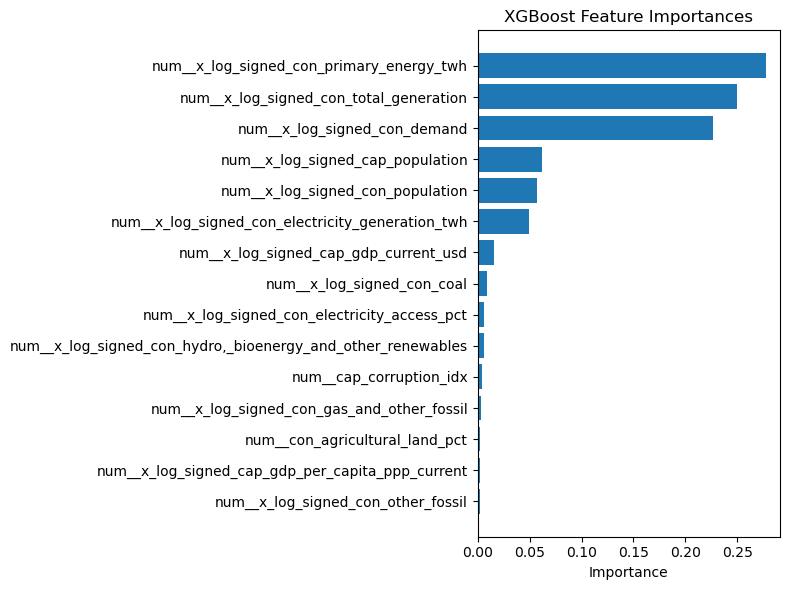

In [102]:
ra.plot_feature_importances(model="XGboost", top_n=15)

In [103]:
feature_names = ra.pipe_enet[:-1].get_feature_names_out()

coefs = ra.pipe_enet.named_steps["enet"].coef_

coef_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": abs(coefs)
    })
    .sort_values("abs_coef", ascending=False)
) 
coef_table.head()


,feature,coef,abs_coef
38,num__x_log_signed_con_primary_energy_twh,3.641025,3.641025
40,num__x_log_signed_cap_population,1.961226,1.961226
39,num__x_log_signed_con_population,1.921384,1.921384
37,num__x_log_signed_cap_gdp_current_usd,1.360429,1.360429
184,cat__iso_alpha_3_URY,0.728148,0.728148


In [104]:
coef_table["type"] = coef_table["feature"].apply(lambda x: x.split("_")[0])
coef_table["clean_feature_name"] = coef_table["feature"].apply(lambda x: "_".join(x.split("_")[2:])) 
coef_table = coef_table[[
    "clean_feature_name",
    "coef",
    "abs_coef",
    "type"
]]
coef_table

,clean_feature_name,coef,abs_coef,type
38,x_log_signed_con_primary_energy_twh,3.641025,3.641025,num
40,x_log_signed_cap_population,1.961226,1.961226,num
39,x_log_signed_con_population,1.921384,1.921384,num
37,x_log_signed_cap_gdp_current_usd,1.360429,1.360429,num
184,iso_alpha_3_URY,0.728148,0.728148,cat
...,...,...,...,...
83,iso_alpha_3_CYP,-0.000000,0.000000,cat
84,iso_alpha_3_CZE,0.000000,0.000000,cat
85,iso_alpha_3_DEU,-0.000000,0.000000,cat
86,iso_alpha_3_DNK,0.000000,0.000000,cat


In [105]:
# Find the features where type is num and abs_coef < 0.01
low_weight_features = coef_table[(coef_table.abs_coef == 0.0) & (coef_table.type == "num")]["clean_feature_name"].values.tolist()
low_weight_features

['cap_electoral_democracy_idx',
 'x_log_signed_inc_n_climate_laws',
 'x_log_signed_con_hydro',
 'x_log_signed_cap_fdi_net_inflows_pct_gdp',
 'x_log_signed_con_demand',
 'x_log_signed_con_hydro,_bioenergy_and_other_renewables',
 'x_log_signed_con_other_fossil',
 'x_log_signed_con_bioenergy',
 'x_log_signed_inc_n_policies_total',
 'x_log_signed_con_energy_per_capita_kwh',
 'x_log_signed_inc_cumulative_climate_laws',
 'x_log_signed_inc_n_sectors_covered',
 'x_log_signed_cap_gdp_per_capita_constant_2015',
 'x_log_signed_inc_carbon_pricing_coverage',
 'x_log_signed_con_gas_and_other_fossil',
 'x_log_signed_con_wind_and_solar',
 'x_log_signed_con_solar',
 'policy_stock',
 'cap_corruption_idx',
 'cap_rule_of_law_idx',
 'cap_accountability_idx',
 'cap_control_corruption',
 'cap_political_stability',
 'cap_regulatory_quality',
 'cap_rule_of_law',
 'con_forest_area_pct',
 'con_net_elec_imports_twh',
 'con_ndgain_score',
 'con_ndgain_vulnerability',
 'con_ndgain_readiness',
 'inc_has_carbon_tax',

In [106]:
# Remove repeated features and also the ones with coefficient 0
redoundant_features = [
    "x_log_signed_cap_gdp_per_capita_ppp_current",
]

features_to_remove = low_weight_features + redoundant_features

In [107]:
coef_table.to_clipboard(index=False)

In [ ]:
training_df_filtered = training_df.drop(columns=features_to_remove)

In [ ]:
features = [col for col in training_df_filtered.columns if col not in ["iso_alpha_3", "year", target_var]]
features

In [ ]:
print("Running regression without group feature...")

ra_2 = RegressionAnalysis(
    df=training_df_filtered,
    target_col=target_var,
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=5,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=features,
    include_year=False
)

ra_2.cross_validate()
ra_2.fit()
ra_2.evaluate()

In [ ]:
feature_names = ra_2.pipe_enet[:-1].get_feature_names_out()

coefs = ra_2.pipe_enet.named_steps["enet"].coef_

coef_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": abs(coefs)
    })
    .sort_values("abs_coef", ascending=False)
) 
coef_table.head()

In [ ]:
coef_table.to_clipboard()

### Notes
- There are repeated features in the data which i've removed.
- per country fixed effects are very important.
- the incentivie features are weak.
